# Getting started with Safe-ICE

Safe-ICE estimates the probability that a system fails, when failing is rare.
The question it answers is

$$P_F = \mathbb{P}(g(u) \le 0), \qquad u \sim \mathcal{N}(0, I_d)$$

where $g$ is a *limit-state function*: negative means failure. The difficulty
is that $P_F$ is small, so drawing from $\mathcal{N}(0, I_d)$ and counting
failures needs roughly $1/P_F$ samples to see any at all.

This notebook runs the estimator on one benchmark and compares it against
doing exactly that.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from safe_ice import SafeICE
from safe_ice.problems.benchmarks import BenchmarkProblems

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})
print("safe-ice", __import__("safe_ice").__version__)

safe-ice 0.3.0


## The problem

The four-mode series system of the paper's section 4.1. It fails when any of
four conditions is met, which puts the failure region in four disconnected
lobes — a proposal that finds only one of them will underestimate the answer.

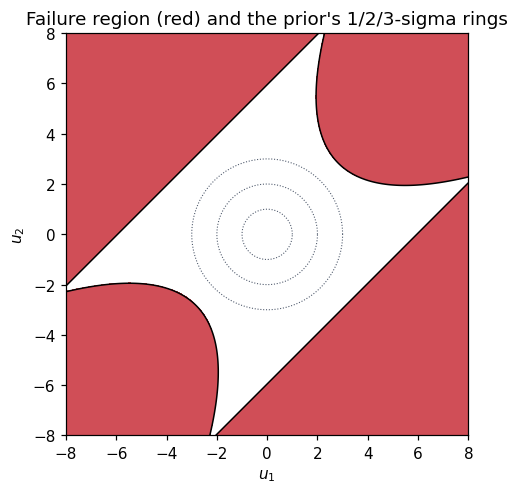

In [2]:
limit_state = BenchmarkProblems.four_mode_series_system(z=1.0)

grid = np.linspace(-8, 8, 400)
X, Y = np.meshgrid(grid, grid)
G = np.asarray(limit_state(np.column_stack([X.ravel(), Y.ravel()]))).reshape(X.shape)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.contourf(
    X, Y, (G <= 0).astype(float), levels=[0.5, 1.5], colors=["#c1121f"], alpha=0.75
)
ax.contour(X, Y, G, levels=[0.0], colors="black", linewidths=1.0)
theta = np.linspace(0, 2 * np.pi, 200)
for r in (1, 2, 3):
    ax.plot(r * np.cos(theta), r * np.sin(theta), color="#4a5568", lw=0.7, ls=":")
ax.set(
    xlabel="$u_1$",
    ylabel="$u_2$",
    title="Failure region (red) and the prior's 1/2/3-sigma rings",
)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

The failure lobes sit well outside the three-sigma ring, which is why this is
a rare event.

## Crude Monte Carlo

The direct approach: sample the prior and count.

In [3]:
rng = np.random.default_rng(20240117)
mc_samples = 2_000_000

g_values = np.asarray(limit_state(rng.standard_normal((mc_samples, 2))))
mc_failures = int((g_values <= 0).sum())
mc_estimate = mc_failures / mc_samples
mc_rel_error = 1.0 / np.sqrt(mc_failures)

print(f"samples   : {mc_samples:,}")
print(f"failures  : {mc_failures}")
print(f"estimate  : {mc_estimate:.4e}  +/- {mc_rel_error:.1%}")

samples   : 2,000,000
failures  : 133
estimate  : 6.6500e-05  +/- 8.7%


Two million evaluations bought a few hundred failures. The relative error of
crude Monte Carlo scales as $1/\sqrt{n P_F}$, so tightening it by a factor of
ten costs a hundred times the samples.

## Safe-ICE

The estimator instead builds a proposal distribution that concentrates on the
failure region, and corrects for the bias with importance weights.

In [4]:
ice = SafeICE(
    limit_state_function=limit_state,
    dimension=2,
    N=1000,
    max_iterations=15,
    random_state=0,
)
pf, results = ice.run(verbose=False)

n_iterations = len(results["iterations"])
evaluations = ice.N * (n_iterations + 1)  # one draw per iteration, plus the final one

print(f"estimate     : {pf:.4e}")
print(f"iterations   : {n_iterations}")
print(f"evaluations  : {evaluations:,}")
print(f"crude MC used: {mc_samples:,}  ({mc_samples / evaluations:.0f}x more)")

estimate     : 5.3656e-05
iterations   : 2
evaluations  : 3,000
crude MC used: 2,000,000  (667x more)


## Against a reference

The reference below is crude Monte Carlo over 2e7 samples, recorded in
`tests/test_benchmark_ground_truth.py`. Both estimates should sit on it.

In [5]:
REFERENCE = 6.465e-05  # 1293 failures in 2e7 samples, +/- 2.8%

print(f"reference (2e7 samples) : {REFERENCE:.4e}")
print(
    f"crude MC (2e6 samples)  : {mc_estimate:.4e}   ratio {mc_estimate / REFERENCE:.3f}"
)
print(f"Safe-ICE ({evaluations:,} evals) : {pf:.4e}   ratio {pf / REFERENCE:.3f}")

reference (2e7 samples) : 6.4650e-05
crude MC (2e6 samples)  : 6.6500e-05   ratio 1.029
Safe-ICE (3,000 evals) : 5.3656e-05   ratio 0.830


## How much does one run vary?

The estimator is stochastic, so a single run is a draw from a distribution.
Quoting one number without its spread would be misleading — seed 0 above is
on the low side. Repeating over seeds shows the actual behaviour.

In [6]:
seeds = range(12)
estimates = np.array(
    [
        SafeICE(
            limit_state_function=limit_state,
            dimension=2,
            N=1000,
            max_iterations=15,
            random_state=s,
        ).run(verbose=False)[0]
        for s in seeds
    ]
)

print(
    f"median  : {np.median(estimates):.4e}   ratio {np.median(estimates) / REFERENCE:.3f}"
)
print(f"range   : {estimates.min():.4e} to {estimates.max():.4e}")
print(
    f"spread  : {estimates.min() / REFERENCE:.2f}x to {estimates.max() / REFERENCE:.2f}x of the reference"
)

median  : 6.4013e-05   ratio 0.990
range   : 5.3656e-05 to 7.6874e-05
spread  : 0.83x to 1.19x of the reference


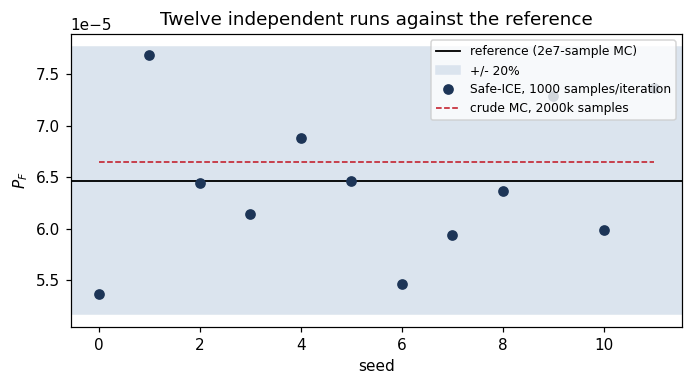

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.axhline(REFERENCE, color="black", lw=1.2, label="reference (2e7-sample MC)")
ax.axhspan(REFERENCE * 0.8, REFERENCE * 1.2, color="#dbe4ee", label="+/- 20%")
ax.plot(
    list(seeds),
    estimates,
    "o",
    color="#1d3557",
    ms=6,
    label="Safe-ICE, 1000 samples/iteration",
)
ax.plot(
    list(seeds),
    [mc_estimate] * len(estimates),
    "--",
    color="#c1121f",
    lw=1.0,
    label=f"crude MC, {mc_samples // 1000}k samples",
)
ax.set(
    xlabel="seed", ylabel="$P_F$", title="Twelve independent runs against the reference"
)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

Every run sits within about 20% of the reference, using three orders of
magnitude fewer evaluations than the crude estimate drawn as the dashed line.

## Where the samples went

The final proposal is what does the work. Drawing from it shows why so few
evaluations suffice.

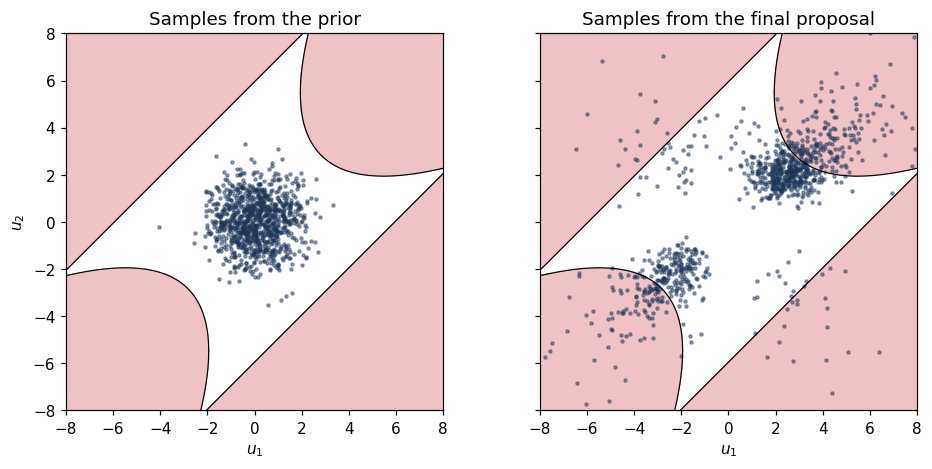

In [8]:
final_params = results["final_parameters"]
proposal = ice._generate_safe_mixture_samples(final_params, results["final_lambda"])
prior = rng.standard_normal((1000, 2))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), sharex=True, sharey=True)
for ax, points, title in (
    (axes[0], prior, "Samples from the prior"),
    (axes[1], proposal, "Samples from the final proposal"),
):
    ax.contourf(
        X, Y, (G <= 0).astype(float), levels=[0.5, 1.5], colors=["#c1121f"], alpha=0.25
    )
    ax.contour(X, Y, G, levels=[0.0], colors="black", linewidths=0.8)
    ax.scatter(points[:, 0], points[:, 1], s=4, alpha=0.45, color="#1d3557")
    ax.set(xlabel="$u_1$", title=title)
    ax.set_aspect("equal")
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
axes[0].set_ylabel("$u_2$")
plt.tight_layout()
plt.show()

The prior barely reaches the red lobes; the adapted proposal covers all four.
Finding every mode is the point of the automatic component selection — a
proposal that locked onto one lobe would return roughly a quarter of the
answer, and would look perfectly converged while doing so.

## What `run()` returns

The second return value carries the diagnostics.

In [9]:
for key in sorted(results):
    value = results[key]
    shape = getattr(value, "shape", None)
    summary = f"array{shape}" if shape is not None else type(value).__name__
    print(f"  {key:22s} {summary}")

print()
print(
    f"final mixture components : {results['final_components']}  (started at K0={ice.K0})"
)
print(f"final sigma              : {results['final_sigma']:.4g}")
print(f"final lambda             : {results['final_lambda']:.4g}")
print(f"unclamped estimate       : {results['pf_unclamped']:.4e}")

  convergence_metrics    dict
  failure_probability    float
  final_components       int
  final_cv               float
  final_g_values         array(2000,)
  final_lambda           float
  final_parameters       vMFNMParameters
  final_samples          array(2000, 2)
  final_sigma            float
  final_weights          array(2000,)
  history                dict
  iterations             list
  pf_unclamped           float

final mixture components : 9  (started at K0=20)
final sigma              : 0.6839
final lambda             : 0.2269
unclamped estimate       : 5.3656e-05


`pf_unclamped` is the estimate before it is constrained to $[0, 1]$. The two
agree here. They differ only when the proposal fails to cover the target, in
which case the returned value is clamped and a warning is raised — an
estimate above 1 is a signal that the run should not be trusted, so it is
reported rather than hidden.